<a href="https://colab.research.google.com/github/Andreina-A/Data620/blob/main/Project1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Andreina Arias <br> Project 1

<b> Gender Difference in Centrality in the Facebook Social Circle Network

The dataset I will analyze in this project will be [Oxford 2005 Facebook Matrix](https://archive.org/details/oxford-2005-facebook-matrix). The dataset contains a snapshot of the Facebook friendship network at a U.S. university in 2005, I will be working with only the data from NYU. The nodes are the students that are Facebook users, and the edges are Facebook friendship links between users. The node attributes (categorical) are gender (Male / Female) is included as a categorical variable. The network contains over 21,679 nodes and approximately 715,715 edges. Using this dataset I would like to answer these questions, do students of different genders differ in degree centrality, are there differences in eigenvector centrality between male and female students,and are observed differences statistically significant across categories.
<br>The goal of this analysis is to determine whether male and female students differ in their positions within the social network.
Specifically, we examine:<br>
• Degree centrality: number of direct friendships <br>
• Eigenvector centrality: influence within the network

<b><u>The Attributes are:</b></u>
<br> Status (Student or Faculty) <br>Gender (1=male, 2=female) <br> Major<br> Second major<br> Dorm <br>Year <br> High School
<br> Column information found on paper written in [the archive website](https://https://dn711103.ca.archive.org/0/items/oxford-2005-facebook-matrix/facebook100_readme_021011.txt).

In [49]:
#Load the dataset and libraries

import requests, zipfile, io, scipy.io
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
import numpy as np


#downloaded the data, open the zip file in memory, selected the NYU network and converted into a networkX graph.
zip_url = "https://archive.org/download/oxford-2005-facebook-matrix/facebook100.zip"
r = requests.get(zip_url)

with zipfile.ZipFile(io.BytesIO(r.content)) as z:
    # Auto-find the file that contains 'NYU' in the url website
    target_name = [f for f in z.namelist() if "NYU" in f][0]

    print(f"Loading: {target_name}")
    with z.open(target_name) as f:
        mat = scipy.io.loadmat(io.BytesIO(f.read()))
        G = nx.from_scipy_sparse_array(mat['A'])

print(f"Success! Graph has {G.number_of_nodes()} nodes.")
print(f"Success! Graph has {G.number_of_edges()} edges.")

Loading: facebook100/NYU9.mat
Success! Graph has 21679 nodes.
Success! Graph has 715715 edges.


In [50]:
#inspected the matrix and dimensions before resigning column labels
print(mat.keys())
print(mat['local_info'].shape) #Shows 7 columns (Attributes) and 21,679 rows

dict_keys(['__header__', '__version__', '__globals__', 'A', 'local_info'])
(21679, 7)


In [51]:
##Extract node attributes/Map gender
#extract node
attributes=mat['local_info']
#Coverted dataset to a dataframe
attributes_df=pd.DataFrame(attributes)

#rename columns
attributes_df.columns= ["status", "gender", "major", "second_major", "dorm", "year", "high_school"]
attributes_df["gender"]= attributes_df["gender"].map({1: "Male", 2: "Female"})

attributes_df.head()

,status,gender,major,second_major,dorm,year,high_school
0,1,Male,0,0,0,2009,17609
1,1,Male,0,0,0,2008,52194
2,1,Female,209,206,57,2007,0
3,2,NaN,0,0,0,0,0
4,1,Female,174,179,27,2008,0


In [48]:
##Compute Centrality Measures
from networkx.algorithms import degree_centrality

#Compute the degree centrality and eigenvector centrality
degree_centrality= nx.degree_centrality(G)
eigenvector_centrality= nx.eigenvector_centrality(G, max_iter=1000)


In [52]:
#Combine centrality with node attributes and a dataframe from the dictionaries
cent_df=pd.DataFrame({
    "node": list(degree_centrality.keys()),
    "degree_centrality": list(degree_centrality.values()),
    "eigenvector_centrality": list(eigenvector_centrality.values())
})

#merged the centrality dataframe with the attribute dataframe
df=pd.concat([cent_df,attributes_df], axis=1)

#keep only nodes with gender information, remove rows with missing gender.
df=df.dropna(subset=["gender"])

df.head()

,node,degree_centrality,eigenvector_centrality,status,gender,major,second_major,dorm,year,high_school
0,0,0.002214,0.002158,1,Male,0,0,0,2009,17609
1,1,0.000046,0.000032,1,Male,0,0,0,2008,52194
2,2,0.006827,0.013521,1,Female,209,206,57,2007,0
4,4,0.001015,0.000640,1,Female,174,179,27,2008,0
5,5,0.002998,0.001891,1,Male,0,0,34,2009,9588


In [53]:
#Compare Centrality by Gender
#Used describe function to display mean, max/min, standard deviation, and median
df.groupby("gender")[["degree_centrality", "eigenvector_centrality"]].describe()


degree_centrality                                                    \
                   count      mean       std       min       25%       50%   
gender                                                                       
Female            8106.0  0.003325  0.003788  0.000046  0.001015  0.002399   
Male             11920.0  0.003014  0.002716  0.000046  0.001107  0.002399   

                           eigenvector_centrality                      \
             75%       max                  count      mean       std   
gender                                                                  
Female  0.004567  0.106790                 8106.0  0.004415  0.006124   
Male    0.004198  0.066611                11920.0  0.004094  0.004722   

                                                              
                 min       25%       50%       75%       max  
gender                                                        
Female  9.689317e-35  0.000810  0.002579  0.005882  0.146719  
Male    9.689317e-35  0.000908  0.002605  0.005714  0.107101

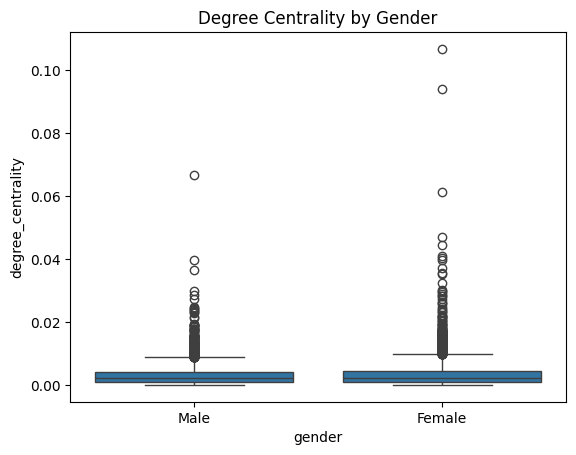

In [54]:
#Boxplot for degree centrality
sns.boxplot(df, x="gender", y="degree_centrality")
plt.title("Degree Centrality by Gender")
plt.show()


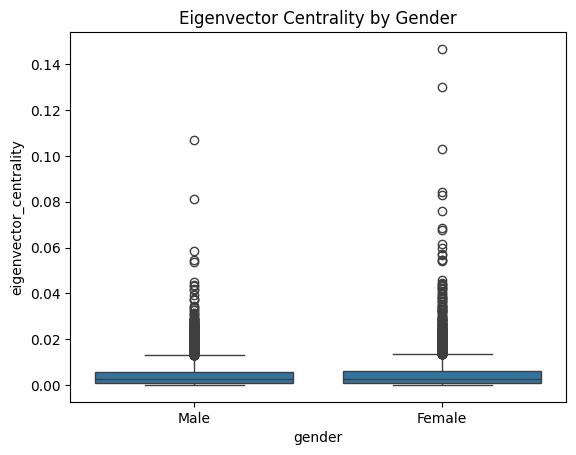

In [55]:
#Boxpot for eigenvetor centrality
sns.boxplot(df, x="gender", y="eigenvector_centrality")
plt.title("Eigenvector Centrality by Gender")
plt.show()

In [56]:
#T-test

male=df[df["gender"] == "Male"]
female=df[df["gender"] == "Female"]

degree_test=ttest_ind(
    male["degree_centrality"],
    female["degree_centrality"],
    nan_policy="omit"
)

eigenvector_test=ttest_ind(
    male["eigenvector_centrality"],
    female["eigenvector_centrality"],
    nan_policy="omit"
)

print("Degree Centrality Test")
print("t-statistic:", round(degree_test.statistic, 4))
print("p-value:", degree_test.pvalue)

print("\nEigenvector Centrality Test")
print("t-statistic:", round(eigenvector_test.statistic, 4))
print("p-value:", eigenvector_test.pvalue)

Degree Centrality Test
t-statistic: -6.7573
p-value: 1.4445666894372212e-11

Eigenvector Centrality Test
t-statistic: -4.1794
p-value: 2.9353105866726045e-05


In [57]:
#Top 5 nodes to graph a readable network graph and that isn't slow to load

top_degree=df.sort_values(by="degree_centrality", ascending=False).head(5)
Top5_nodes=top_degree["node"].tolist()

#Get their neighbors
neighbors=set()
for node in Top5_nodes:
    neighbors.update(G.neighbors(node))

sub_node=set(Top5_nodes).union(neighbors)

#subset
sub_graph=G.subgraph(sub_node)

#Dictionary
gender_dict=dict(zip(df["node"], df["gender"]))

#assign color by sex
color_map=[]
for node in sub_graph.nodes():
    gender=gender_dict.get(node, None)

    if gender == "Male":
        color_map.append("blue")
    elif gender == "Female":
        color_map.append("red")
    else:
        color_map.append("gray")

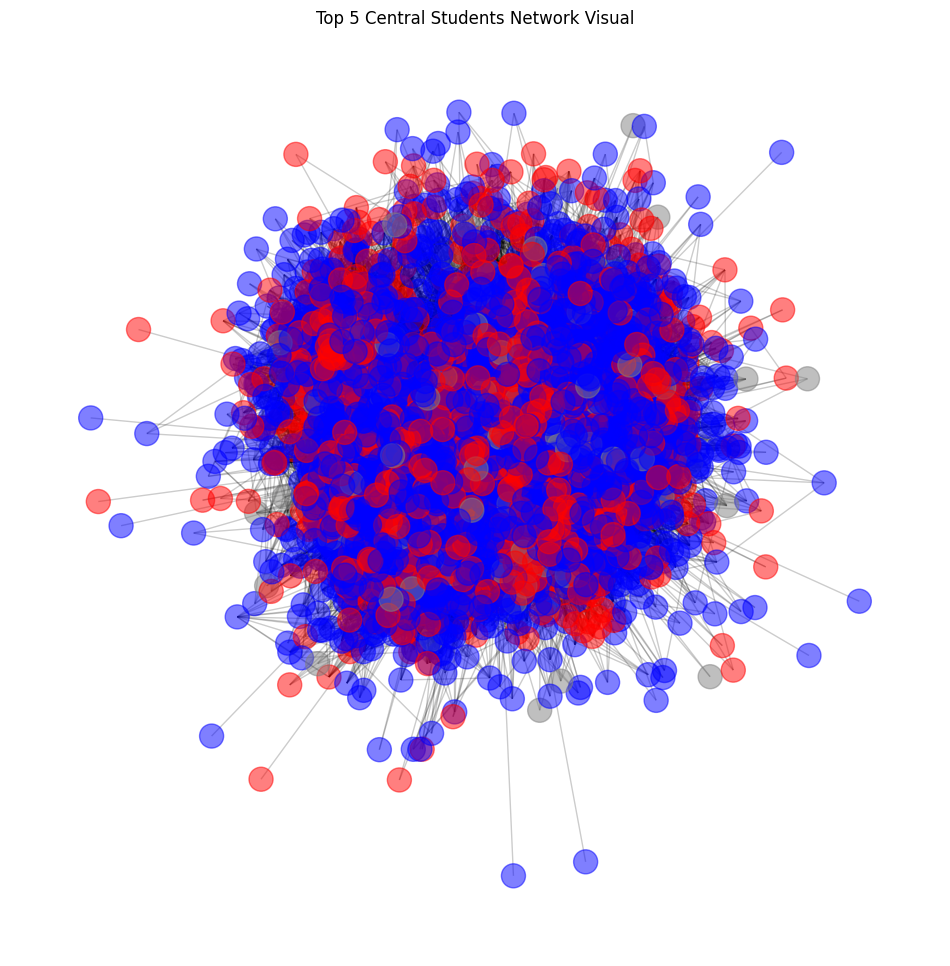

In [58]:
#Plot network of top 5 nodes
plt.figure(figsize=(12,12))
pos= nx.spring_layout(sub_graph, seed=41, k=0.15) #set seed and parameters k=0.15 to try to graph a little faster.
nx.draw_networkx_nodes(sub_graph, pos, node_color=color_map, alpha=0.5)
nx.draw_networkx_edges(sub_graph, pos, alpha=0.2)

plt.title("Top 5 Central Students Network Visual")
plt.axis("off")
plt.show()

The boxplot show that the females had more further away outlier then males for both degree and eignvector centrality. The T test results indicate that the observed differences are statically signicant since the p values are less than 0.05. Femelas had a high average degree centrality compared to males meaning that they tend to have more direct friendships in the networks. Females also had a high average for eigenvector centrality suggesting the females may occupy more influential positions with the network compared to males.